In [6]:
import os
import pandas as pd
import numpy as np
from pathlib import Path

def load_fall_detection_data(base_dir="./Tests"):
    """
    Load fall detection dataset
    
    Args:
        base_dir: Base directory containing the Tests folder (default: "./Tests")
        
    Returns:
        dict: Contains loaded data with metadata
    """
    data_collection = []
    
    # Iterate through all participant folders (e.g., 101, 102, etc.)
    for participant_folder in os.listdir(base_dir):
        if not os.path.isdir(os.path.join(base_dir, participant_folder)):
            continue
            
        participant_id = participant_folder
        
        # Check if folder contains digits (participant ID)
        if not participant_id.isdigit():
            continue
            
        participant_path = os.path.join(base_dir, participant_folder)
        
        # Read participant info from Bilgi.txt
        bilgi_path = os.path.join(participant_path, "Bilgi.txt")
        participant_info = load_participant_info(bilgi_path)
        
        # Load from 'Testler Export' folder
        testler_export_path = os.path.join(participant_path, "Testler Export")
        if not os.path.exists(testler_export_path):
            continue
            
        # Iterate through activity folders (801-YurumeIleri, 902-OneDogruUzanma, etc.)
        for activity_folder in os.listdir(testler_export_path):
            if not os.path.isdir(os.path.join(testler_export_path, activity_folder)):
                continue
                
            # Extract activity code from folder name
            activity_code = activity_folder.split('-')[0]
            activity_path = os.path.join(testler_export_path, activity_folder)
            
            # Iterate through test folders (Test_1, Test_2, etc.)
            for test_folder in os.listdir(activity_path):
                test_path = os.path.join(activity_path, test_folder)
                
                if not os.path.isdir(test_path):
                    continue
                    
                # Load sensor data for this test
                sensor_data = load_test_sensors(test_path)
                
                # Create record for this test
                record = {
                    'participant_id': participant_id,
                    'participant_info': participant_info,
                    'activity_code': activity_code,
                    'activity_name': activity_folder,
                    'test_id': test_folder,
                    'sensor_data': sensor_data
                }
                
                data_collection.append(record)
    
    return data_collection

def load_participant_info(bilgi_path):
    """Extract participant information from Bilgi.txt"""
    if not os.path.exists(bilgi_path):
        return {}
        
    info = {}
    with open(bilgi_path, 'r', encoding='utf-8') as f:
        for line in f:
            if ':' in line:
                key, value = line.strip().split(':', 1)
                # Map Turkish keys to English
                key_mapping = {
                    'Ad': 'name',
                    'Soyad': 'surname',
                    'Cinsiyet': 'gender',
                    'Kilo': 'weight',
                    'Boy': 'height',
                    'Yaş': 'age',
                    'Tel': 'telephone'
                }
                info[key_mapping.get(key, key)] = value.strip()
    
    return info

def load_test_sensors(test_path):
    """Load sensor data from a test folder"""
    sensor_data = {}
    
    # Load each sensor file
    for sensor_file in os.listdir(test_path):
        if sensor_file.endswith('.txt'):
            sensor_id = sensor_file.replace('.txt', '')
            sensor_path = os.path.join(test_path, sensor_file)
            
            # Find the header line
            header_line = None
            with open(sensor_path, 'r') as f:
                for line_num, line in enumerate(f):
                    if line.startswith('Counter'):
                        header_line = line_num
                        break
            
            # Read data starting from the header line
            if header_line is not None:
                data = pd.read_csv(sensor_path, delimiter='\t', skiprows=header_line)
            else:
                # Fallback: try reading without skipping
                data = pd.read_csv(sensor_path, delimiter='\t')
            
            # Map sensor ID to body location
            sensor_locations = {
                '340506': 'head',
                '340527': 'chest', 
                '340535': 'waist',
                '340537': 'right_wrist',
                '340539': 'right_thigh',
                '340540': 'right_ankle'
            }
            
            location = sensor_locations.get(sensor_id, 'unknown')
            sensor_data[location] = data
    
    return sensor_data

# Example usage:
data = load_fall_detection_data()  # This will automatically use "./Tests"
print(f"Loaded {len(data)} samples")
# 
# # Access first sample
# sample = data[0]
# print(f"Participant: {sample['participant_id']}")
# print(f"Activity: {sample['activity_name']}")
# print(f"Test: {sample['test_id']}")
# print(f"Waist sensor data shape: {sample['sensor_data']['waist'].shape}")

Loaded 3326 samples


In [ ]:
# Access first sample
sample = data[0]
print(f"Participant: {sample['participant_id']}")
print(f"Activity: {sample['activity_name']}")
print(f"Test: {sample['test_id']}")
print(f"Waist sensor data shape: {sample['sensor_data']['waist'].shape}")

Participant: 101
Activity: 801-Yurume Ileri
Test: Test_1
Waist sensor data shape: (616, 24)


In [13]:
def get_dataset_summary(data_collection):
    """
    Get a summary of the fall detection dataset
    
    Args:
        data_collection: List of dictionaries containing the loaded data
        
    Returns:
        dict: Summary statistics of the dataset
    """
    summary = {
        'total_samples': len(data_collection),
        'unique_participants': set(),
        'gender_distribution': {},
        'activity_types': {},
        'fall_activities': {},
        'daily_activities': {},
        'sensors_per_sample': {},
        'total_sensors_available': set()
    }
    
    # Analyze each sample
    for sample in data_collection:
        # Participant information
        summary['unique_participants'].add(sample['participant_id'])
        
        # Gender distribution (if available)
        if 'gender' in sample['participant_info']:
            gender = sample['participant_info']['gender']
            summary['gender_distribution'][gender] = summary['gender_distribution'].get(gender, 0) + 1
        
        # Activity classification
        activity_code = sample['activity_code']
        activity_name = sample['activity_name']
        summary['activity_types'][activity_name] = summary['activity_types'].get(activity_name, 0) + 1
        
        # Classify as fall or daily activity
        if activity_code.startswith('9'):
            summary['fall_activities'][activity_name] = summary['fall_activities'].get(activity_name, 0) + 1
        else:
            summary['daily_activities'][activity_name] = summary['daily_activities'].get(activity_name, 0) + 1
        
        # Sensor information
        available_sensors = list(sample['sensor_data'].keys())
        sensor_key = tuple(sorted(available_sensors))
        summary['sensors_per_sample'][sensor_key] = summary['sensors_per_sample'].get(sensor_key, 0) + 1
        
        # Track all available sensors
        for sensor in available_sensors:
            summary['total_sensors_available'].add(sensor)
    
    # Convert sets to lists for better display
    summary['unique_participants'] = sorted(list(summary['unique_participants']))
    summary['total_sensors_available'] = sorted(list(summary['total_sensors_available']))
    
    # Calculate percentages
    total_samples = summary['total_samples']
    summary['fall_activity_percentage'] = (sum(summary['fall_activities'].values()) / total_samples) * 100
    summary['daily_activity_percentage'] = (sum(summary['daily_activities'].values()) / total_samples) * 100
    
    return summary

# Usage example (run this in your notebook after loading the data)
summary = get_dataset_summary(data)
print(f"Total samples: {summary['total_samples']}")
print(f"Number of participants: {len(summary['unique_participants'])}")
print(f"Participants: {summary['unique_participants']}")
print(f"\nGender distribution:")
for gender, count in summary['gender_distribution'].items():
    print(f"  {gender}: {count}")
print(f"\nActivity types breakdown:")
print(f"  Fall activities: {summary['fall_activity_percentage']:.1f}%")
print(f"  Daily activities: {summary['daily_activity_percentage']:.1f}%")
print(f"\nAvailable sensors: {summary['total_sensors_available']}")

Total samples: 3326
Number of participants: 17
Participants: ['101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '203', '204', '205', '206', '207', '208', '209']

Gender distribution:

Activity types breakdown:
  Fall activities: 55.4%
  Daily activities: 44.6%

Available sensors: ['chest', 'head', 'right_ankle', 'right_thigh', 'right_wrist', 'unknown', 'waist']


In [14]:
def analyze_participant_demographics(data_collection):
    """
    Analyze participant demographics and test statistics
    
    Args:
        data_collection: List of dictionaries containing the loaded data
        
    Returns:
        dict: Detailed participant information and test statistics
    """
    participant_stats = {}
    test_activity_breakdown = {}
    
    for sample in data_collection:
        participant_id = sample['participant_id']
        
        # Initialize participant stats if not exists
        if participant_id not in participant_stats:
            participant_stats[participant_id] = {
                'participant_info': sample['participant_info'],
                'total_tests': 0,
                'activities_performed': set(),
                'fall_tests': 0,
                'daily_living_tests': 0
            }
        
        # Update test counts
        participant_stats[participant_id]['total_tests'] += 1
        participant_stats[participant_id]['activities_performed'].add(sample['activity_name'])
        
        # Count fall vs daily activities
        if sample['activity_code'].startswith('9'):
            participant_stats[participant_id]['fall_tests'] += 1
        else:
            participant_stats[participant_id]['daily_living_tests'] += 1
    
    # Convert sets to lists for better display
    for p_id in participant_stats:
        participant_stats[p_id]['activities_performed'] = list(participant_stats[p_id]['activities_performed'])
    
    # Get overall activity statistics
    for sample in data_collection:
        activity_code = sample['activity_code']
        activity_name = sample['activity_name']
        
        if activity_code not in test_activity_breakdown:
            test_activity_breakdown[activity_code] = {
                'name': activity_name,
                'count': 0,
                'participants': set()
            }
        
        test_activity_breakdown[activity_code]['count'] += 1
        test_activity_breakdown[activity_code]['participants'].add(sample['participant_id'])
    
    # Convert participant sets to counts
    for activity in test_activity_breakdown:
        test_activity_breakdown[activity]['unique_participants'] = len(test_activity_breakdown[activity]['participants'])
        del test_activity_breakdown[activity]['participants']
    
    # Identify the unknown sensor issue
    unknown_sensors = []
    for sample in data_collection:
        if 'unknown' in sample['sensor_data']:
            unknown_sensors.append({
                'participant': sample['participant_id'],
                'activity': sample['activity_name'],
                'test': sample['test_id']
            })
    
    return {
        'participant_stats': participant_stats,
        'activity_breakdown': test_activity_breakdown,
        'unknown_sensors': unknown_sensors[:5]  # Show first 5 examples
    }

# Function to analyze the raw data fields in Bilgi.txt
def debug_participant_info(data_collection):
    """Debug function to check the raw participant information"""
    for sample in data_collection[:3]:  # Check first 3 samples
        print(f"Participant {sample['participant_id']}:")
        print(f"Raw info: {sample['participant_info']}")
        print("-" * 50)

# Run these in your notebook
results = analyze_participant_demographics(data)

# Display participant overview
print("Participant Overview:")
print(f"Total participants: {len(results['participant_stats'])}")
for p_id, stats in sorted(results['participant_stats'].items()):
    print(f"\nParticipant {p_id}:")
    print(f"  Total tests: {stats['total_tests']}")
    print(f"  Fall tests: {stats['fall_tests']}")
    print(f"  Daily living tests: {stats['daily_living_tests']}")
    print(f"  Activities performed: {len(stats['activities_performed'])}")
    # Check if we have age and height data
    if 'age' in stats['participant_info'] and stats['participant_info']['age']:
        print(f"  Age: {stats['participant_info']['age']}")
    if 'height' in stats['participant_info'] and stats['participant_info']['height']:
        print(f"  Height: {stats['participant_info']['height']}")

# Display activity breakdown
print("\n" + "="*50)
print("Activity Breakdown (top 10 most frequent):")
sorted_activities = sorted(results['activity_breakdown'].items(), 
                          key=lambda x: x[1]['count'], 
                          reverse=True)[:10]
for code, info in sorted_activities:
    activity_type = "Fall" if code.startswith('9') else "Daily Living"
    print(f"Code {code}: {info['name']}")
    print(f"  Type: {activity_type}")
    print(f"  Count: {info['count']}")
    print(f"  Participants: {info['unique_participants']}")
    print("-" * 30)

# Investigate unknown sensors
print("\n" + "="*50)
print("Unknown Sensor Investigation (first 5 cases):")
for i, case in enumerate(results['unknown_sensors'][:5]):
    print(f"Case {i+1}:")
    print(f"  Participant: {case['participant']}")
    print(f"  Activity: {case['activity']}")
    print(f"  Test: {case['test']}")

# Debug participant info parsing
print("\n" + "="*50)
print("Debug Participant Info Parsing:")
debug_participant_info(data)

Participant Overview:
Total participants: 17

Participant 101:
  Total tests: 197
  Fall tests: 100
  Daily living tests: 97
  Activities performed: 36

Participant 102:
  Total tests: 182
  Fall tests: 101
  Daily living tests: 81
  Activities performed: 36

Participant 103:
  Total tests: 181
  Fall tests: 101
  Daily living tests: 80
  Activities performed: 36

Participant 104:
  Total tests: 181
  Fall tests: 101
  Daily living tests: 80
  Activities performed: 36

Participant 105:
  Total tests: 180
  Fall tests: 100
  Daily living tests: 80
  Activities performed: 36

Participant 106:
  Total tests: 182
  Fall tests: 101
  Daily living tests: 81
  Activities performed: 36

Participant 107:
  Total tests: 216
  Fall tests: 120
  Daily living tests: 96
  Activities performed: 36

Participant 108:
  Total tests: 215
  Fall tests: 119
  Daily living tests: 96
  Activities performed: 36

Participant 109:
  Total tests: 216
  Fall tests: 120
  Daily living tests: 96
  Activities perfor

In [15]:
def fix_and_analyze_data_quality(data_collection):
    """
    Fix parsing issues and analyze data quality
    
    Args:
        data_collection: List of dictionaries containing the loaded data
        
    Returns:
        dict: Comprehensive analysis of data quality
    """
    # Fix participant info - remove extra spaces from keys
    for sample in data_collection:
        fixed_info = {}
        for key, value in sample['participant_info'].items():
            cleaned_key = key.strip()
            fixed_info[cleaned_key] = value
        sample['participant_info'] = fixed_info
    
    # Investigate unknown sensors
    sensor_id_investigation = {}
    sensor_data_quality = {
        'sensors': {},
        'missing_data': [],
        'sensor_coverage': {}
    }
    
    # Expected sensors based on documentation
    expected_sensors = {
        '340506': 'head',
        '340527': 'chest', 
        '340535': 'waist',
        '340537': 'right_wrist',
        '340539': 'right_thigh',
        '340540': 'right_ankle'
    }
    
    # Analyze each sample
    for sample in data_collection:
        sample_key = f"{sample['participant_id']}-{sample['activity_code']}-{sample['test_id']}"
        
        # Check each sensor in the sample
        for sensor_id, data in sample['sensor_data'].items():
            if sensor_id == 'unknown':
                # Find the actual sensor ID by checking the test folder
                test_path = os.path.join(
                    "./Tests", 
                    sample['participant_id'], 
                    "Testler Export", 
                    sample['activity_name'], 
                    sample['test_id']
                )
                
                # Get all .txt files in this test folder
                txt_files = [f for f in os.listdir(test_path) if f.endswith('.txt')]
                
                sensor_id_investigation[sample_key] = {
                    'participant': sample['participant_id'],
                    'activity': sample['activity_name'],
                    'test': sample['test_id'],
                    'found_files': txt_files
                }
            
            # Check data quality for all sensors
            if sensor_id not in sensor_data_quality['sensors']:
                sensor_data_quality['sensors'][sensor_id] = {
                    'total_samples': 0,
                    'empty_data': 0,
                    'average_records': 0,
                    'data_shapes': {}
                }
            
            sensor_info = sensor_data_quality['sensors'][sensor_id]
            sensor_info['total_samples'] += 1
            
            # Check if data is empty
            if data.empty:
                sensor_info['empty_data'] += 1
            else:
                # Check data shape
                shape_key = str(data.shape)
                sensor_info['data_shapes'][shape_key] = sensor_info['data_shapes'].get(shape_key, 0) + 1
        
        # Check sensor coverage per sample
        available_sensors = set(sample['sensor_data'].keys())
        coverage_key = tuple(sorted(available_sensors))
        sensor_data_quality['sensor_coverage'][coverage_key] = sensor_data_quality['sensor_coverage'].get(coverage_key, 0) + 1
    
    # Update fixed gender distribution
    gender_distribution = {}
    for sample in data_collection:
        if 'Gender' in sample['participant_info']:
            gender = sample['participant_info']['Gender']
            gender_distribution[gender] = gender_distribution.get(gender, 0) + 1
    
    return {
        'sensor_id_investigation': sensor_id_investigation,
        'sensor_data_quality': sensor_data_quality,
        'gender_distribution': gender_distribution,
        'expected_sensor_mapping': expected_sensors
    }

# Test the unknown sensor issue specifically
def investigate_unknown_sensor_case(data_collection, case_index=0):
    """Investigate a specific unknown sensor case in detail"""
    unknown_cases = [sample for sample in data_collection if 'unknown' in sample['sensor_data']]
    
    if unknown_cases:
        case = unknown_cases[case_index]
        test_path = os.path.join(
            "./Tests", 
            case['participant_id'], 
            "Testler Export", 
            case['activity_name'], 
            case['test_id']
        )
        
        print(f"Investigating case: {case['participant_id']}-{case['activity_name']}-{case['test_id']}")
        print(f"Test path: {test_path}")
        print("\nFiles in test folder:")
        
        for filename in os.listdir(test_path):
            if filename.endswith('.txt'):
                file_id = filename.replace('.txt', '')
                expected_location = expected_sensors.get(file_id, 'Not in mapping')
                print(f"  {filename} -> ID: {file_id} -> Expected: {expected_location}")
                
                # Show a preview of file content
                with open(os.path.join(test_path, filename), 'r') as f:
                    content_preview = f.read(200)  # First 200 characters
                    print(f"    Preview: {content_preview[:100]}...")
                    print(f"    Contains 'Counter': {'Counter' in content_preview}")
                    print("-" * 50)

# Run the analysis
quality_analysis = fix_and_analyze_data_quality(data)

# Print fixed gender distribution
print("Fixed Gender Distribution:")
for gender, count in quality_analysis['gender_distribution'].items():
    print(f"  {gender}: {count}")

# Print sensor data quality summary
print("\nSensor Data Quality Summary:")
for sensor, info in quality_analysis['sensor_data_quality']['sensors'].items():
    print(f"\n{sensor} sensor:")
    print(f"  Total samples: {info['total_samples']}")
    print(f"  Empty data: {info['empty_data']}")
    print(f"  Unique shapes: {list(info['data_shapes'].keys())}")

# Investigate the first unknown sensor case
print("\n" + "="*50)
print("Unknown Sensor Investigation:")
investigate_unknown_sensor_case(data)

# Check sensor coverage
print("\n" + "="*50)
print("Sensor Coverage Distribution:")
for coverage, count in quality_analysis['sensor_data_quality']['sensor_coverage'].items():
    print(f"  {coverage}: {count} samples")

Fixed Gender Distribution:
  Male: 1967
  Female: 1359

Sensor Data Quality Summary:

head sensor:
  Total samples: 3321
  Empty data: 0
  Unique shapes: ['(616, 24)', '(649, 24)', '(648, 24)', '(611, 24)', '(592, 24)', '(678, 24)', '(659, 24)', '(669, 24)', '(651, 24)', '(686, 24)', '(516, 24)', '(515, 24)', '(534, 24)', '(509, 24)', '(554, 24)', '(464, 24)', '(460, 24)', '(484, 24)', '(470, 24)', '(521, 24)', '(529, 24)', '(407, 24)', '(335, 24)', '(374, 24)', '(349, 24)', '(370, 24)', '(377, 24)', '(414, 24)', '(411, 24)', '(380, 24)', '(388, 24)', '(362, 24)', '(428, 24)', '(668, 24)', '(644, 24)', '(687, 24)', '(656, 24)', '(695, 24)', '(717, 24)', '(531, 24)', '(572, 24)', '(555, 24)', '(589, 24)', '(575, 24)', '(543, 24)', '(594, 24)', '(566, 24)', '(568, 24)', '(557, 24)', '(580, 24)', '(588, 24)', '(333, 24)', '(314, 24)', '(341, 24)', '(322, 24)', '(313, 24)', '(303, 24)', '(331, 24)', '(372, 24)', '(382, 24)', '(385, 24)', '(364, 24)', '(412, 24)', '(430, 24)', '(422, 24)', 

NameError: name 'expected_sensors' is not defined

In [16]:
# Fix the investigate_unknown_sensor_case function
def investigate_unknown_sensor_case(data_collection, expected_sensors, case_index=0):
    """Investigate a specific unknown sensor case in detail"""
    unknown_cases = [sample for sample in data_collection if 'unknown' in sample['sensor_data']]
    
    if unknown_cases:
        case = unknown_cases[case_index]
        test_path = os.path.join(
            "./Tests", 
            case['participant_id'], 
            "Testler Export", 
            case['activity_name'], 
            case['test_id']
        )
        
        print(f"Investigating case: {case['participant_id']}-{case['activity_name']}-{case['test_id']}")
        print(f"Test path: {test_path}")
        print("\nFiles in test folder:")
        
        for filename in os.listdir(test_path):
            if filename.endswith('.txt'):
                file_id = filename.replace('.txt', '')
                expected_location = expected_sensors.get(file_id, 'Not in mapping')
                print(f"  {filename} -> ID: {file_id} -> Expected: {expected_location}")
                
                # Show a preview of file content
                with open(os.path.join(test_path, filename), 'r') as f:
                    content_preview = f.read(200)  # First 200 characters
                    print(f"    Preview: {content_preview[:100]}...")
                    print(f"    Contains 'Counter': {'Counter' in content_preview}")
                    print("-" * 50)

# Run it with the expected_sensors dictionary
expected_sensors = {
    '340506': 'head',
    '340527': 'chest', 
    '340535': 'waist',
    '340537': 'right_wrist',
    '340539': 'right_thigh',
    '340540': 'right_ankle'
}

# Now investigate the unknown sensor case
print("\n" + "="*50)
print("Unknown Sensor Investigation:")
investigate_unknown_sensor_case(data, expected_sensors)


Unknown Sensor Investigation:
Investigating case: 103-911-GeriyeDogruSagli-Test_5
Test path: ./Tests\103\Testler Export\911-GeriyeDogruSagli\Test_5

Files in test folder:
  340506.txt -> ID: 340506 -> Expected: head
    Preview: // Start Time: 0
// Update Rate: 25.0Hz
// Scenario: 34.3
// Firmware Version: 1.0.7
Counter	Tempera...
    Contains 'Counter': True
--------------------------------------------------
  340527.txt -> ID: 340527 -> Expected: chest
    Preview: // Start Time: 0
// Update Rate: 25.0Hz
// Scenario: 34.3
// Firmware Version: 1.0.7
Counter	Tempera...
    Contains 'Counter': True
--------------------------------------------------
  340535.txt -> ID: 340535 -> Expected: waist
    Preview: // Start Time: 0
// Update Rate: 25.0Hz
// Scenario: 34.3
// Firmware Version: 1.0.7
Counter	Tempera...
    Contains 'Counter': True
--------------------------------------------------
  340537.txt -> ID: 340537 -> Expected: right_wrist
    Preview: // Start Time: 0
// Update Rate: 25

In [17]:
def fix_sensor_loading(base_dir="./Tests"):
    """
    Fix sensor loading to handle all sensor files correctly
    
    Returns:
        list: Updated data collection with fixed sensor data
    """
    data_collection = []
    
    # Complete sensor mapping including the problematic ones
    sensor_locations = {
        '340506': 'head',
        '340527': 'chest', 
        '340535': 'waist',
        '340537': 'right_wrist',
        '340539': 'right_thigh',
        '340540': 'right_ankle',
        '535': 'waist',  # It appears this is also waist sensor (shortened ID)
        '506': 'head',   # Possibly shortened IDs
        '527': 'chest',
        '537': 'right_wrist',
        '539': 'right_thigh',
        '540': 'right_ankle'
    }
    
    for participant_folder in os.listdir(base_dir):
        if not os.path.isdir(os.path.join(base_dir, participant_folder)):
            continue
            
        participant_id = participant_folder
        if not participant_id.isdigit():
            continue
            
        participant_path = os.path.join(base_dir, participant_folder)
        bilgi_path = os.path.join(participant_path, "Bilgi.txt")
        participant_info = load_participant_info(bilgi_path)
        
        testler_export_path = os.path.join(participant_path, "Testler Export")
        if not os.path.exists(testler_export_path):
            continue
            
        for activity_folder in os.listdir(testler_export_path):
            if not os.path.isdir(os.path.join(testler_export_path, activity_folder)):
                continue
                
            activity_code = activity_folder.split('-')[0]
            activity_path = os.path.join(testler_export_path, activity_folder)
            
            for test_folder in os.listdir(activity_path):
                test_path = os.path.join(activity_path, test_folder)
                
                if not os.path.isdir(test_path):
                    continue
                
                # Fix sensor loading
                sensor_data = {}
                for sensor_file in os.listdir(test_path):
                    if sensor_file.endswith('.txt'):
                        sensor_id = sensor_file.replace('.txt', '')
                        sensor_path = os.path.join(test_path, sensor_file)
                        
                        # Try to read the file with different approaches
                        try:
                            # First, try to find header
                            header_line = None
                            with open(sensor_path, 'r') as f:
                                for line_num, line in enumerate(f):
                                    if line.startswith('Counter'):
                                        header_line = line_num
                                        break
                            
                            if header_line is not None:
                                data = pd.read_csv(sensor_path, delimiter='\t', skiprows=header_line)
                            else:
                                # If no header, check if it has 24 columns (including counter)
                                data = pd.read_csv(sensor_path, delimiter='\t')
                                if len(data.columns) == 24:
                                    # Manually set column names
                                    columns = ['Counter', 'Temperature', 'VelInc_X', 'VelInc_Y', 'VelInc_Z', 
                                              'OriInc_w', 'OriInc_x', 'OriInc_y', 'OriInc_z', 
                                              'Acc_X', 'Acc_Y', 'Acc_Z', 
                                              'Gyr_X', 'Gyr_Y', 'Gyr_Z', 
                                              'Mag_X', 'Mag_Y', 'Mag_Z', 
                                              'Pressure', 'Roll', 'Pitch', 'Yaw', 'RSSI']
                                    data.columns = columns
                            
                            # Map sensor ID to location
                            location = sensor_locations.get(sensor_id, 'unknown')
                            sensor_data[location] = data
                            
                        except Exception as e:
                            print(f"Error reading {sensor_path}: {e}")
                
                record = {
                    'participant_id': participant_id,
                    'participant_info': participant_info,
                    'activity_code': activity_code,
                    'activity_name': activity_folder,
                    'test_id': test_folder,
                    'sensor_data': sensor_data
                }
                
                data_collection.append(record)
    
    return data_collection

# Run this to get corrected data
print("Reloading data with fixed sensor mapping...")
fixed_data = fix_sensor_loading()
print(f"Loaded {len(fixed_data)} samples")

# Check if we still have unknown sensors
unknown_count = 0
for sample in fixed_data:
    if 'unknown' in sample['sensor_data']:
        unknown_count += 1

print(f"Unknown sensors remaining: {unknown_count}")

# Get updated summary
if unknown_count == 0:
    summary = get_dataset_summary(fixed_data)
    print("\nUpdated sensor summary:")
    print(f"Available sensors: {summary['total_sensors_available']}")

Reloading data with fixed sensor mapping...
Error reading ./Tests\103\Testler Export\911-GeriyeDogruSagli\Test_5\535.txt: Length mismatch: Expected axis has 24 elements, new values have 23 elements
Loaded 3326 samples
Unknown sensors remaining: 1


In [18]:
def extract_advanced_features(data_collection, sensor_selection='waist_only'):
    """
    Extract advanced features from sensor data for fall detection
    
    Args:
        data_collection: List of dictionaries containing the loaded data
        sensor_selection: Strategy for sensor selection ('waist_only', 'waist_chest', or 'all')
        
    Returns:
        tuple: (features DataFrame, labels Series)
    """
    import numpy as np
    from scipy.fft import fft
    
    # Define sensors based on selection strategy
    if sensor_selection == 'waist_only':
        focus_sensors = ['waist']
    elif sensor_selection == 'waist_chest':
        focus_sensors = ['waist', 'chest']
    else:  # 'all'
        focus_sensors = ['waist', 'chest', 'head', 'right_wrist', 'right_thigh', 'right_ankle']
    
    print(f"Using sensor selection: {sensor_selection} ({', '.join(focus_sensors)})")
    
    # Prepare dataframe
    features = []
    labels = []
    
    # Track which samples are processed successfully
    processed_count = 0
    skipped_count = 0
    
    for sample in data_collection:
        try:
            # Create base feature dict
            feature_dict = {
                'participant_id': sample['participant_id'],
                'activity_code': sample['activity_code'],
                'activity_name': sample['activity_name'],
                'test_id': sample['test_id']
            }
            
            # Is this a fall or daily activity?
            is_fall = 1 if sample['activity_code'].startswith('9') else 0
            feature_dict['is_fall'] = is_fall
            
            # Extract detailed label
            activity_label = int(sample['activity_code'])
            
            # Extract features from each sensor
            all_sensors_present = True
            
            for sensor in focus_sensors:
                if sensor not in sample['sensor_data']:
                    all_sensors_present = False
                    continue
                
                # Get sensor data
                sensor_df = sample['sensor_data'][sensor]
                
                if sensor_df.empty:
                    all_sensors_present = False
                    continue
                
                # Calculate features for this sensor
                try:
                    # 1. Time-domain statistical features
                    # Accelerometer features
                    for axis in ['X', 'Y', 'Z']:
                        acc_col = f'Acc_{axis}'
                        if acc_col not in sensor_df.columns:
                            continue
                            
                        values = sensor_df[acc_col].values
                        
                        # Basic statistics
                        feature_dict[f'{sensor}_acc_{axis}_mean'] = np.mean(values)
                        feature_dict[f'{sensor}_acc_{axis}_std'] = np.std(values)
                        feature_dict[f'{sensor}_acc_{axis}_max'] = np.max(values)
                        feature_dict[f'{sensor}_acc_{axis}_min'] = np.min(values)
                        feature_dict[f'{sensor}_acc_{axis}_range'] = np.max(values) - np.min(values)
                        
                        # Percentiles
                        feature_dict[f'{sensor}_acc_{axis}_25th'] = np.percentile(values, 25)
                        feature_dict[f'{sensor}_acc_{axis}_75th'] = np.percentile(values, 75)
                        
                        # Zero crossing rate
                        zero_crossings = np.where(np.diff(np.signbit(values)))[0]
                        feature_dict[f'{sensor}_acc_{axis}_zero_crossings'] = len(zero_crossings)
                    
                    # 2. Overall acceleration magnitude (vector magnitude)
                    if all(col in sensor_df.columns for col in ['Acc_X', 'Acc_Y', 'Acc_Z']):
                        acc_mag = np.sqrt(
                            sensor_df['Acc_X']**2 + 
                            sensor_df['Acc_Y']**2 + 
                            sensor_df['Acc_Z']**2
                        )
                        
                        feature_dict[f'{sensor}_acc_mag_mean'] = np.mean(acc_mag)
                        feature_dict[f'{sensor}_acc_mag_std'] = np.std(acc_mag)
                        feature_dict[f'{sensor}_acc_mag_max'] = np.max(acc_mag)
                        feature_dict[f'{sensor}_acc_mag_min'] = np.min(acc_mag)
                        feature_dict[f'{sensor}_acc_mag_range'] = np.max(acc_mag) - np.min(acc_mag)
                        
                        # 3. Signal Magnitude Area (SMA)
                        window_size = min(50, len(sensor_df))  # Use smaller window if data is short
                        sma = 0
                        for i in range(len(sensor_df) - window_size + 1):
                            window = acc_mag[i:i+window_size]
                            sma += np.sum(window) / window_size
                        
                        # Normalize by number of windows
                        if len(sensor_df) > window_size:
                            sma /= (len(sensor_df) - window_size + 1)
                        
                        feature_dict[f'{sensor}_sma'] = sma
                        
                        # 4. Jerk (derivative of acceleration)
                        jerk_x = np.diff(sensor_df['Acc_X'])
                        jerk_y = np.diff(sensor_df['Acc_Y'])
                        jerk_z = np.diff(sensor_df['Acc_Z'])
                        
                        # Jerk magnitude
                        jerk_mag = np.sqrt(jerk_x**2 + jerk_y**2 + jerk_z**2)
                        
                        feature_dict[f'{sensor}_jerk_mag_mean'] = np.mean(jerk_mag)
                        feature_dict[f'{sensor}_jerk_mag_max'] = np.max(jerk_mag)
                        feature_dict[f'{sensor}_jerk_mag_std'] = np.std(jerk_mag)
                    
                    # 5. Frequency-domain features
                    if len(sensor_df) >= 64:  # Need sufficient data for FFT
                        for axis in ['X', 'Y', 'Z']:
                            acc_col = f'Acc_{axis}'
                            if acc_col not in sensor_df.columns:
                                continue
                                
                            # Apply FFT
                            fft_values = fft(sensor_df[acc_col].values[:64])
                            # Take the magnitude of the first 10 frequencies
                            fft_mag = np.abs(fft_values[:10])
                            
                            # Store dominant frequency
                            feature_dict[f'{sensor}_acc_{axis}_dom_freq'] = np.argmax(fft_mag[1:]) + 1
                            # Energy in frequency domain
                            feature_dict[f'{sensor}_acc_{axis}_freq_energy'] = np.sum(fft_mag**2)
                    
                    # 6. Gyroscope features (angular velocity)
                    if all(col in sensor_df.columns for col in ['Gyr_X', 'Gyr_Y', 'Gyr_Z']):
                        gyr_mag = np.sqrt(
                            sensor_df['Gyr_X']**2 + 
                            sensor_df['Gyr_Y']**2 + 
                            sensor_df['Gyr_Z']**2
                        )
                        
                        feature_dict[f'{sensor}_gyr_mag_mean'] = np.mean(gyr_mag)
                        feature_dict[f'{sensor}_gyr_mag_std'] = np.std(gyr_mag)
                        feature_dict[f'{sensor}_gyr_mag_max'] = np.max(gyr_mag)
                        
                        # Angular velocity peak-to-peak
                        feature_dict[f'{sensor}_gyr_mag_p2p'] = np.max(gyr_mag) - np.min(gyr_mag)
                    
                    # 7. Orientation features
                    for angle in ['Roll', 'Pitch', 'Yaw']:
                        if angle in sensor_df.columns:
                            values = sensor_df[angle].values
                            feature_dict[f'{sensor}_{angle.lower()}_mean'] = np.mean(values)
                            feature_dict[f'{sensor}_{angle.lower()}_range'] = np.max(values) - np.min(values)
                            feature_dict[f'{sensor}_{angle.lower()}_std'] = np.std(values)
                    
                    # 8. Correlation between axes
                    if all(col in sensor_df.columns for col in ['Acc_X', 'Acc_Y', 'Acc_Z']):
                        corr_xy = np.corrcoef(sensor_df['Acc_X'], sensor_df['Acc_Y'])[0, 1]
                        corr_xz = np.corrcoef(sensor_df['Acc_X'], sensor_df['Acc_Z'])[0, 1]
                        corr_yz = np.corrcoef(sensor_df['Acc_Y'], sensor_df['Acc_Z'])[0, 1]
                        
                        feature_dict[f'{sensor}_acc_corr_xy'] = corr_xy
                        feature_dict[f'{sensor}_acc_corr_xz'] = corr_xz
                        feature_dict[f'{sensor}_acc_corr_yz'] = corr_yz
                
                except Exception as e:
                    print(f"Error processing sensor {sensor} for sample {sample['participant_id']}-{sample['activity_name']}-{sample['test_id']}: {e}")
                    all_sensors_present = False
            
            # Only add samples where all required sensors were successfully processed
            if all_sensors_present:
                features.append(feature_dict)
                labels.append(activity_label)
                processed_count += 1
            else:
                skipped_count += 1
                
        except Exception as e:
            print(f"Error processing sample {sample['participant_id']}-{sample['activity_name']}-{sample['test_id']}: {e}")
            skipped_count += 1
    
    print(f"Successfully processed {processed_count} samples")
    print(f"Skipped {skipped_count} samples")
    
    # Convert to pandas DataFrame
    features_df = pd.DataFrame(features)
    labels_series = pd.Series(labels, name='activity_label')
    
    # Print feature set statistics
    print(f"Feature set shape: {features_df.shape}")
    print(f"Number of features: {features_df.shape[1]}")
    print(f"Number of fall samples: {features_df['is_fall'].sum()}")
    print(f"Number of non-fall samples: {len(features_df) - features_df['is_fall'].sum()}")
    
    return features_df, labels_series

# Run the feature extraction with just the waist sensor
features_waist, labels_waist = extract_advanced_features(fixed_data, sensor_selection='waist_only')

# Display the first few features to check
columns = [col for col in features_waist.columns if col.startswith('waist_')][:10]
print("\nSample waist features (first 5 rows, 10 feature columns):")
print(features_waist[columns].head(5))

Using sensor selection: waist_only (waist)
Successfully processed 3324 samples
Skipped 2 samples
Feature set shape: (3324, 60)
Number of features: 60
Number of fall samples: 1842
Number of non-fall samples: 1482

Sample waist features (first 5 rows, 10 feature columns):
   waist_acc_X_mean  waist_acc_X_std  waist_acc_X_max  waist_acc_X_min  \
0          9.788932         0.882232        13.992810         7.647920   
1               NaN              NaN              NaN              NaN   
2          9.776789         0.959038        13.764954         6.872559   
3          9.779851         0.991444        13.815975         6.890392   
4          9.766017         0.994399        14.618278         6.776977   

   waist_acc_X_range  waist_acc_X_25th  waist_acc_X_75th  \
0           6.344891          9.695739          9.820557   
1                NaN               NaN               NaN   
2           6.892395          9.725952          9.798050   
3           6.925583          9.711576      

In [19]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from imblearn.over_sampling import SMOTE

def preprocess_fall_detection_data(features_df, labels_series, normalization='standard', 
                                  balance_data=True, test_size=0.2, random_state=42):
    """
    Perform preprocessing steps for fall detection dataset including handling
    missing values, normalization, and train/test split
    
    Args:
        features_df: DataFrame containing features extracted from sensor data
        labels_series: Series containing activity labels
        normalization: Type of normalization to use ('standard', 'minmax', or None)
        balance_data: Whether to balance classes using SMOTE
        test_size: Proportion of data to use for testing
        random_state: Random seed for reproducibility
        
    Returns:
        tuple: (X_train, X_test, y_train, y_test, scaler)
    """
    print("Starting data preprocessing...")
    
    # Make a copy to avoid modifying original data
    features = features_df.copy()
    labels = labels_series.copy()
    
    # Get metadata columns (non-feature columns to exclude from normalization)
    metadata_cols = ['participant_id', 'activity_code', 'activity_name', 'test_id', 'is_fall']
    feature_cols = [col for col in features.columns if col not in metadata_cols]
    
    # 1. Handle missing values
    print(f"Initial shape: {features.shape}")
    missing_count = features[feature_cols].isnull().sum().sum()
    print(f"Total missing values: {missing_count}")
    
    if missing_count > 0:
        # Option 1: Drop rows with any missing values
        # features = features.dropna()
        
        # Option 2: Fill missing values with column mean (better for feature-based analysis)
        for col in feature_cols:
            if features[col].isnull().any():
                col_mean = features[col].mean()
                features[col].fillna(col_mean, inplace=True)
    
    # 2. Normalize features
    if normalization:
        print(f"Applying {normalization} normalization...")
        if normalization == 'standard':
            scaler = StandardScaler()
        elif normalization == 'minmax':
            scaler = MinMaxScaler()
        else:
            raise ValueError("Normalization method must be 'standard', 'minmax', or None")
        
        # Fit and transform only the feature columns, not metadata
        features[feature_cols] = scaler.fit_transform(features[feature_cols])
    else:
        scaler = None
    
    # 3. Split data into features and target
    X = features[feature_cols]
    y = labels
    
    # 4. Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                      test_size=test_size, 
                                                      random_state=random_state,
                                                      stratify=features['is_fall'])
    
    # 5. Balance training data if requested
    if balance_data:
        print("Balancing training data with SMOTE...")
        smote = SMOTE(random_state=random_state)
        X_train, y_train = smote.fit_resample(X_train, y_train)
        print(f"After SMOTE - X_train shape: {X_train.shape}")
    
    print("Preprocessing complete!")
    print(f"Training set: {X_train.shape[0]} samples")
    print(f"Testing set: {X_test.shape[0]} samples")
    
    return X_train, X_test, y_train, y_test, scaler

# Run the preprocessing on your data
X_train, X_test, y_train, y_test, scaler = preprocess_fall_detection_data(
    features_waist, labels_waist, normalization='standard', balance_data=True
)

# Check class distribution in training and testing sets
print("\nClass distribution in training set:")
print(pd.Series(y_train).value_counts())
print("\nClass distribution in testing set:")
print(pd.Series(y_test).value_counts())

Starting data preprocessing...
Initial shape: (3324, 60)
Total missing values: 23946
Applying standard normalization...
Balancing training data with SMOTE...
After SMOTE - X_train shape: (2988, 55)
Preprocessing complete!
Training set: 2988 samples
Testing set: 665 samples

Class distribution in training set:
activity_label
920    83
904    83
908    83
918    83
812    83
903    83
905    83
915    83
909    83
913    83
813    83
916    83
910    83
902    83
801    83
806    83
901    83
802    83
906    83
809    83
804    83
907    83
919    83
807    83
803    83
814    83
816    83
810    83
912    83
815    83
917    83
914    83
911    83
805    83
808    83
811    83
Name: count, dtype: int64

Class distribution in testing set:
activity_label
902    28
802    27
810    24
812    24
917    24
912    23
811    22
913    21
916    21
901    20
904    20
919    20
903    20
905    20
918    19
805    19
813    19
816    19
804    19
915    18
910    18
815    17
907    17
801    


Training SVM...
SVM Accuracy: 0.7684
              precision    recall  f1-score   support

         801       0.55      0.65      0.59        17
         802       1.00      0.56      0.71        27
         803       1.00      0.79      0.88        14
         804       0.82      0.74      0.78        19
         805       1.00      0.95      0.97        19
         806       0.88      0.50      0.64        14
         807       0.35      0.57      0.43        14
         808       0.56      0.64      0.60        14
         809       0.50      0.53      0.51        17
         810       0.91      0.88      0.89        24
         811       0.41      0.73      0.52        22
         812       0.79      0.62      0.70        24
         813       0.93      0.74      0.82        19
         814       0.47      0.44      0.45        16
         815       0.94      0.88      0.91        17
         816       1.00      1.00      1.00        19
         901       0.57      0.60      0.59

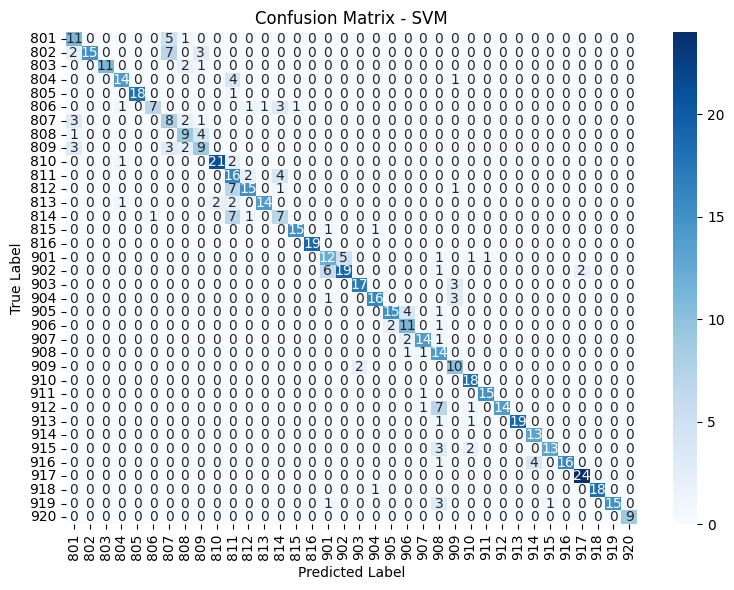


Training Random Forest...
Random Forest Accuracy: 0.9023
              precision    recall  f1-score   support

         801       0.84      0.94      0.89        17
         802       1.00      0.85      0.92        27
         803       1.00      1.00      1.00        14
         804       0.95      0.95      0.95        19
         805       1.00      1.00      1.00        19
         806       0.93      0.93      0.93        14
         807       0.90      0.64      0.75        14
         808       0.56      0.71      0.62        14
         809       0.58      0.65      0.61        17
         810       1.00      0.96      0.98        24
         811       0.90      0.86      0.88        22
         812       1.00      0.83      0.91        24
         813       1.00      1.00      1.00        19
         814       0.71      0.94      0.81        16
         815       1.00      0.94      0.97        17
         816       1.00      1.00      1.00        19
         901       0.73

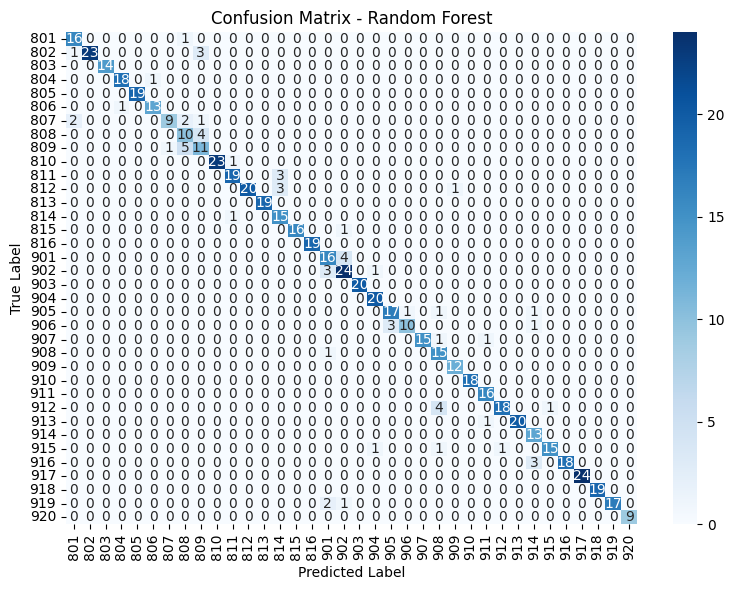


Training Gradient Boosting...
Gradient Boosting Accuracy: 0.8376
              precision    recall  f1-score   support

         801       0.79      0.88      0.83        17
         802       1.00      0.67      0.80        27
         803       1.00      1.00      1.00        14
         804       0.78      0.95      0.86        19
         805       0.94      0.89      0.92        19
         806       0.79      0.79      0.79        14
         807       0.75      0.64      0.69        14
         808       0.56      0.64      0.60        14
         809       0.57      0.76      0.65        17
         810       0.96      0.92      0.94        24
         811       0.70      0.73      0.71        22
         812       1.00      0.79      0.88        24
         813       0.94      0.89      0.92        19
         814       0.59      0.81      0.68        16
         815       1.00      0.82      0.90        17
         816       1.00      1.00      1.00        19
         901   

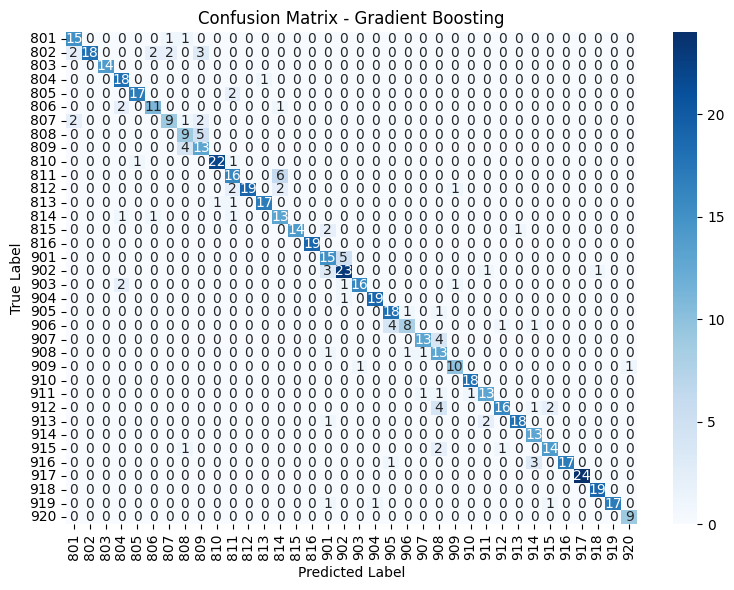


Training KNN...
KNN Accuracy: 0.7699
              precision    recall  f1-score   support

         801       0.52      0.82      0.64        17
         802       0.89      0.59      0.71        27
         803       0.93      1.00      0.97        14
         804       0.56      0.74      0.64        19
         805       1.00      0.95      0.97        19
         806       0.86      0.86      0.86        14
         807       0.69      0.64      0.67        14
         808       0.64      0.64      0.64        14
         809       0.50      0.53      0.51        17
         810       0.87      0.83      0.85        24
         811       0.48      0.50      0.49        22
         812       0.85      0.71      0.77        24
         813       0.81      0.68      0.74        19
         814       0.71      0.75      0.73        16
         815       0.94      0.94      0.94        17
         816       1.00      1.00      1.00        19
         901       0.36      0.60      0.45

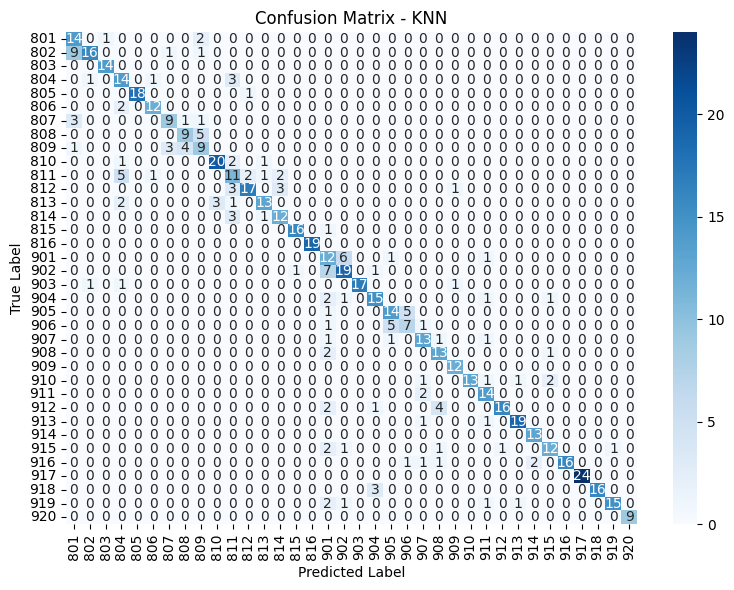


Best model: Random Forest with accuracy 0.9023


In [20]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_fall_detection_models(X_train, X_test, y_train, y_test):
    """
    Evaluate multiple machine learning models for fall detection
    
    Args:
        X_train, X_test, y_train, y_test: Training and testing data
        
    Returns:
        dict: Dictionary of trained models and their performance metrics
    """
    # Define models to evaluate
    models = {
        'SVM': SVC(kernel='rbf', probability=True, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42),
        'KNN': KNeighborsClassifier(n_neighbors=5)
    }
    
    results = {}
    
    # Evaluate each model
    for name, model in models.items():
        print(f"\nTraining {name}...")
        model.fit(X_train, y_train)
        
        # Predict on test set
        y_pred = model.predict(X_test)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, output_dict=True)
        
        # Store results
        results[name] = {
            'model': model,
            'accuracy': accuracy,
            'report': report,
            'predictions': y_pred
        }
        
        print(f"{name} Accuracy: {accuracy:.4f}")
        print(classification_report(y_test, y_pred))
        
        # Plot confusion matrix
        plt.figure(figsize=(8, 6))
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=sorted(set(y_test)), 
                   yticklabels=sorted(set(y_test)))
        plt.title(f'Confusion Matrix - {name}')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.tight_layout()
        plt.show()
    
    return results

# Run model evaluation
model_results = evaluate_fall_detection_models(X_train, X_test, y_train, y_test)

# Identify the best performing model
best_model = max(model_results.items(), key=lambda x: x[1]['accuracy'])
print(f"\nBest model: {best_model[0]} with accuracy {best_model[1]['accuracy']:.4f}")

Starting binary fall detection preprocessing...
Fall samples: 1842
Non-fall samples: 1482
Initial shape: (3324, 60)
Total missing values: 23946
Applying standard normalization...
Preprocessing complete!
Training set: 2659 samples
Testing set: 665 samples

Training SVM for binary fall detection...
SVM Accuracy: 0.9925
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       296
           1       0.99      1.00      0.99       369

    accuracy                           0.99       665
   macro avg       0.99      0.99      0.99       665
weighted avg       0.99      0.99      0.99       665



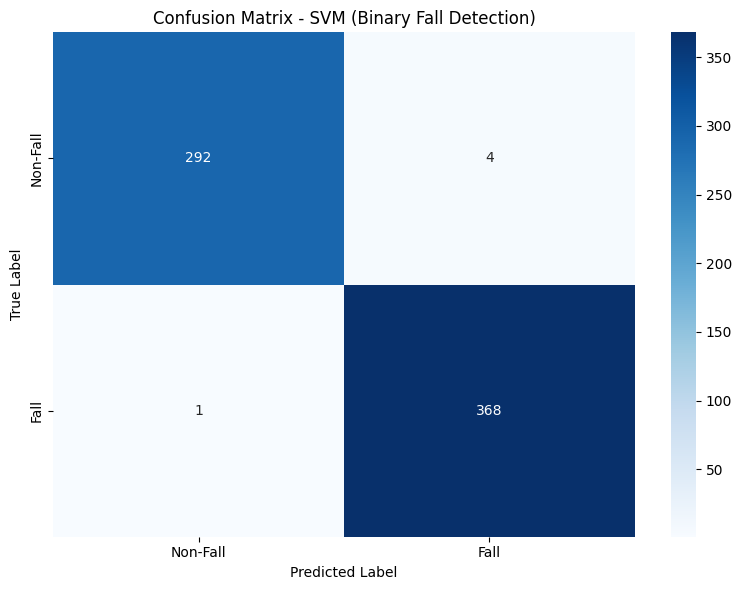


Training Random Forest for binary fall detection...
Random Forest Accuracy: 0.9940
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       296
           1       0.99      1.00      0.99       369

    accuracy                           0.99       665
   macro avg       0.99      0.99      0.99       665
weighted avg       0.99      0.99      0.99       665



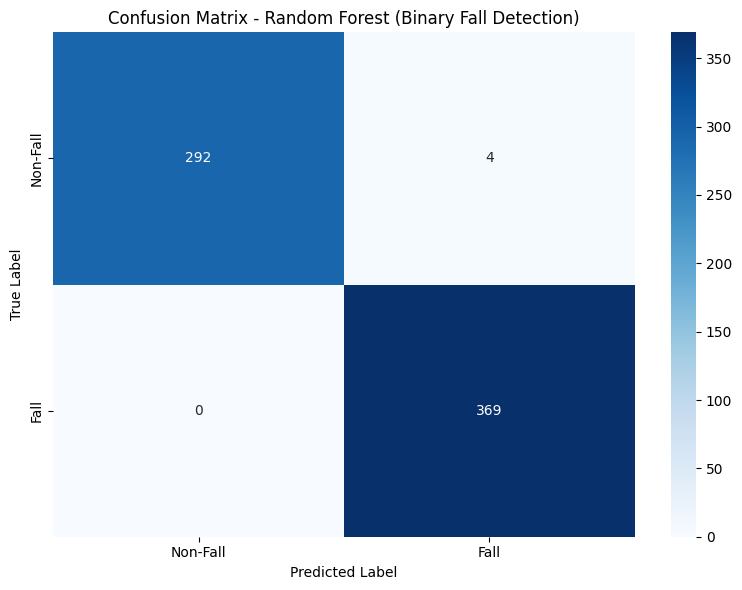


Training Gradient Boosting for binary fall detection...
Gradient Boosting Accuracy: 0.9955
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       296
           1       0.99      1.00      1.00       369

    accuracy                           1.00       665
   macro avg       1.00      1.00      1.00       665
weighted avg       1.00      1.00      1.00       665



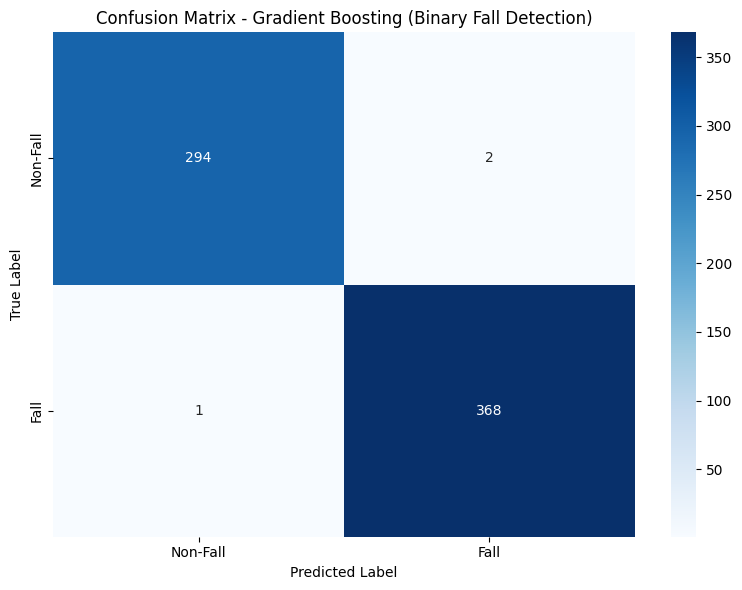


Training KNN for binary fall detection...
KNN Accuracy: 0.9925
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       296
           1       0.99      0.99      0.99       369

    accuracy                           0.99       665
   macro avg       0.99      0.99      0.99       665
weighted avg       0.99      0.99      0.99       665



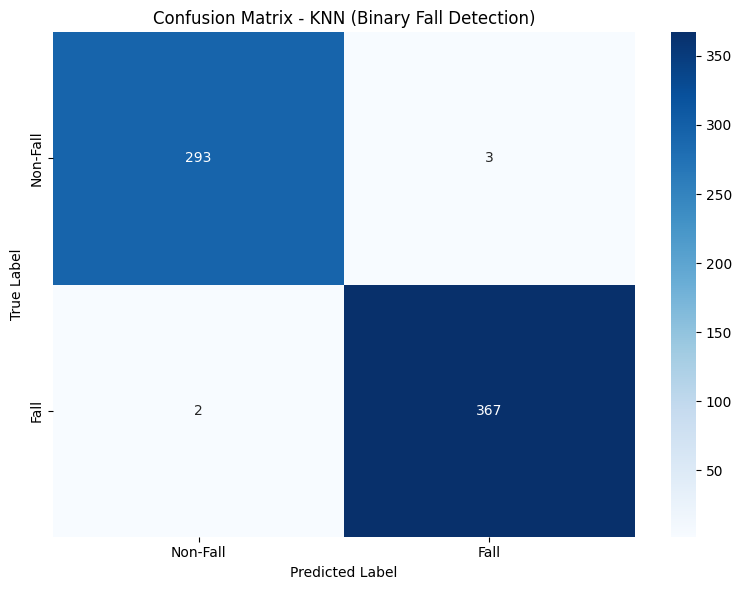

In [21]:
def preprocess_fall_detection_data_binary(features_df, labels_series, normalization='standard', 
                                  test_size=0.2, random_state=42):
    """
    Perform preprocessing for binary fall detection (fall vs. non-fall)
    
    Args:
        features_df: DataFrame containing features extracted from sensor data
        labels_series: Series containing activity labels
        normalization: Type of normalization to use ('standard', 'minmax', or None)
        test_size: Proportion of data to use for testing
        random_state: Random seed for reproducibility
        
    Returns:
        tuple: (X_train, X_test, y_train, y_test, scaler)
    """
    print("Starting binary fall detection preprocessing...")
    
    # Make a copy to avoid modifying original data
    features = features_df.copy()
    
    # Create binary labels (1 for fall, 0 for non-fall)
    # Assuming activity codes starting with 9 are falls
    binary_labels = labels_series.apply(lambda x: 1 if str(x).startswith('9') else 0)
    
    print(f"Fall samples: {binary_labels.sum()}")
    print(f"Non-fall samples: {len(binary_labels) - binary_labels.sum()}")
    
    # Get metadata columns (non-feature columns to exclude from normalization)
    metadata_cols = ['participant_id', 'activity_code', 'activity_name', 'test_id', 'is_fall']
    feature_cols = [col for col in features.columns if col not in metadata_cols]
    
    # 1. Handle missing values
    print(f"Initial shape: {features.shape}")
    missing_count = features[feature_cols].isnull().sum().sum()
    print(f"Total missing values: {missing_count}")
    
    if missing_count > 0:
        # Fill missing values with column mean
        for col in feature_cols:
            if features[col].isnull().any():
                col_mean = features[col].mean()
                features[col].fillna(col_mean, inplace=True)
    
    # 2. Normalize features
    if normalization:
        print(f"Applying {normalization} normalization...")
        if normalization == 'standard':
            scaler = StandardScaler()
        elif normalization == 'minmax':
            scaler = MinMaxScaler()
        else:
            raise ValueError("Normalization method must be 'standard', 'minmax', or None")
        
        # Fit and transform only the feature columns, not metadata
        features[feature_cols] = scaler.fit_transform(features[feature_cols])
    else:
        scaler = None
    
    # 3. Split data into features and target
    X = features[feature_cols]
    y = binary_labels
    
    # 4. Train/test split - stratify by binary label
    X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                      test_size=test_size, 
                                                      random_state=random_state,
                                                      stratify=y)
    
    print("Preprocessing complete!")
    print(f"Training set: {X_train.shape[0]} samples")
    print(f"Testing set: {X_test.shape[0]} samples")
    
    return X_train, X_test, y_train, y_test, scaler

def evaluate_binary_fall_detection(X_train, X_test, y_train, y_test):
    """
    Evaluate binary fall detection models
    
    Args:
        X_train, X_test, y_train, y_test: Training and testing data
        
    Returns:
        dict: Dictionary of trained models and their performance metrics
    """
    # Define models to evaluate
    models = {
        'SVM': SVC(kernel='rbf', probability=True, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42),
        'KNN': KNeighborsClassifier(n_neighbors=5)
    }
    
    results = {}
    
    # Evaluate each model
    for name, model in models.items():
        print(f"\nTraining {name} for binary fall detection...")
        model.fit(X_train, y_train)
        
        # Predict on test set
        y_pred = model.predict(X_test)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, output_dict=True)
        
        # Store results
        results[name] = {
            'model': model,
            'accuracy': accuracy,
            'report': report,
            'predictions': y_pred
        }
        
        print(f"{name} Accuracy: {accuracy:.4f}")
        print(classification_report(y_test, y_pred))
        
        # Plot confusion matrix
        plt.figure(figsize=(8, 6))
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=['Non-Fall', 'Fall'], 
                   yticklabels=['Non-Fall', 'Fall'])
        plt.title(f'Confusion Matrix - {name} (Binary Fall Detection)')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.tight_layout()
        plt.show()
    
    return results

# Run binary preprocessing
X_train, X_test, y_train, y_test, scaler = preprocess_fall_detection_data_binary(
    features_waist, labels_waist, normalization='standard'
)

# Run binary fall detection evaluation
binary_results = evaluate_binary_fall_detection(X_train, X_test, y_train, y_test)